<a href="https://colab.research.google.com/github/fabel134/yeast_mapping_in_metagenomes/blob/main/260504_Copia_de_figure1C_colab_multi_reference_refs_separados_DOCUMENTED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Figura tipo 1C multi-referencia para muestras metagenómicas de *Saccharomyces*

Este notebook analiza las tablas `*.10kb_similarity.csv` generadas por tu pipeline de ventanas de 10 kb.

La lógica general es:

```text
BAM filtrado + VCF filtrado
↓
ventanas de 10 kb
↓
N_sites, SNPs_d, divergence, similarity
↓
figuras y resúmenes por referencia/muestra
```

La métrica `similarity_N_over_dplus1` está inspirada en la Figura 1C del artículo *High-Resolution Mapping of Complex Traits with a Four-Parent Advanced Intercross Yeast Population*:

```text
similarity = N / (d + 1)
```

donde:

- `N` = número de sitios comparables en una ventana
- `d` = número de diferencias de un solo nucleótido

En tu adaptación:

- cada muestra metagenómica se compara contra varias referencias
- cada referencia se analiza por separado
- los resultados se resumen por ventana, por cromosoma, por muestra y por referencia

## 1. Instalar librerías

Este notebook usa:

- `pandas` para leer y resumir tablas
- `matplotlib` para hacer figuras

En Colab normalmente ya están instaladas, pero esta celda asegura que estén disponibles.

In [1]:
!pip -q install pandas matplotlib

## 2. Conectar Google Drive

Colab no puede leer directamente los archivos de tu cluster.  
Por eso, los resultados de `results_by_ref/` deben estar copiados a Google Drive.

Estructura esperada:

```text
MyDrive/yeast/results_by_ref/
├── AAR/
│   └── windows_10kb/
│       ├── SRR27931704.10kb_similarity.csv
│       └── ...
├── ADE/
│   └── windows_10kb/
│       ├── SRR27931704.10kb_similarity.csv
│       └── ...
└── ...
```

In [3]:
from google.colab import drive
drive.mount('/content/drive')
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive
Mounted at /content/drive


In [4]:
ls -lh drive/MyDrive/yeast/


total 296K
drwx------ 2 root root 4.0K Apr 21 06:02 1C/
drwx------ 2 root root 4.0K Apr 23 21:20 figures_1C_like/
drwx------ 2 root root 4.0K May  5 02:18 figures_1C_multi_ref/
drwx------ 2 root root 4.0K Apr 20 23:25 heatmaps_por_muestra/
drwx------ 2 root root 4.0K May  6 18:38 results_by_ref/
drwx------ 2 root root 4.0K May  7 02:11 results_by_ref_500/
drwx------ 2 root root 4.0K May  7 04:07 results_by_ref_5000/
drwx------ 2 root root 4.0K May 12 07:15 results_by_ref_controles/
drwx------ 2 root root 4.0K May 12 07:13 results_by_ref_controles_v1/
-rw------- 1 root root 260K Apr 17 06:28 tabla_final.tsv


In [5]:
ls -lh drive/MyDrive/yeast/results_by_ref_controles


total 4.0K
drwx------ 2 root root 4.0K May 12 07:15 SGD_2010/


## 3. Configuración general

Edita estas rutas si tus resultados están en otra carpeta.

Parámetros importantes:

- `RESULTS_ROOT`: carpeta principal con resultados separados por referencia
- `OUTPUT_DIR`: carpeta donde se guardarán figuras y tablas resumen
- `MIN_N_SITES`: mínimo de sitios comparables por ventana
- `MAX_SAMPLES_TO_PLOT`: limita cuántas muestras se grafican para evitar figuras saturadas

In [6]:
import os
import glob
import re

import pandas as pd
import matplotlib.pyplot as plt

# Carpeta con resultados por referencia
#RESULTS_ROOT = '/content/drive/MyDrive/yeast/results_by_ref_1'
RESULTS_ROOT = '/content/drive/MyDrive/yeast/results_by_ref_controles'
RESULTS_ROOT_controles = '/content/drive/MyDrive/yeast/results_by_ref_controles'

# Carpeta de salida para figuras y tablas resumen
#OUTPUT_DIR = '/content/drive/MyDrive/yeast/results_by_ref_1'
OUTPUT_DIR = '/content/drive/MyDrive/yeast/results_by_ref'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Filtro mínimo de sitios comparables por ventana
MIN_N_SITES = 5

# Si tienes muchas muestras, puedes limitar el número graficado.
# Usa None para graficar todas.
MAX_SAMPLES_TO_PLOT = None

print('RESULTS_ROOT:', RESULTS_ROOT)
print('RESULTS_ROOT_controles:', RESULTS_ROOT_controles)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('MIN_N_SITES:', MIN_N_SITES)
print('MAX_SAMPLES_TO_PLOT:', MAX_SAMPLES_TO_PLOT)

RESULTS_ROOT: /content/drive/MyDrive/yeast/results_by_ref_controles
RESULTS_ROOT_controles: /content/drive/MyDrive/yeast/results_by_ref_controles
OUTPUT_DIR: /content/drive/MyDrive/yeast/results_by_ref
MIN_N_SITES: 5
MAX_SAMPLES_TO_PLOT: None


## 4. Detectar referencias disponibles

Cada subcarpeta dentro de `RESULTS_ROOT` se interpreta como una referencia.

Ejemplo:

```text
results_by_ref/AAR/
results_by_ref/ADE/
results_by_ref/SGD_2010/
```

El nombre de la carpeta se usa como nombre de referencia.

In [7]:
ref_dirs = sorted([
    d for d in glob.glob(os.path.join(RESULTS_ROOT, '*'))
    if os.path.isdir(d)
])

references = [os.path.basename(d) for d in ref_dirs]

print(f'Referencias encontradas: {len(references)}')
print(references)

Referencias encontradas: 1
['SGD_2010']


In [8]:
ls $RESULTS_ROOT/SGD_2010/windows_10kb

Scerevisiae_opt1.10kb_similarity.csv  Scerevisiae_opt3.10kb_similarity.csv
Scerevisiae_opt2.10kb_similarity.csv  Scerevisiae_opt4.10kb_similarity.csv


## 5. Funciones auxiliares

Estas funciones hacen tres cosas:

1. ordenar cromosomas correctamente (`chr1`, `chr2`, ..., `chr16`)
2. cargar todas las tablas de una referencia
3. preparar los datos para análisis y figuras

Columnas esperadas en cada CSV:

- `sample`
- `chrom`
- `start`
- `end`
- `N_sites`
- `SNPs_d`
- `divergence_d_over_N`
- `similarity_N_over_dplus1`

Significado:

- `N_sites`: posiciones comparables dentro de una ventana
- `SNPs_d`: SNPs detectados en esa ventana
- `divergence_d_over_N`: proporción de posiciones diferentes en la ventana
- `similarity_N_over_dplus1`: sitios comparables por diferencia, inspirado en la Figura 1C

natural_chr_key(chrom): Esta función se encarga de ordenar los cromosomas.

In [9]:

def natural_chr_key(chrom):
    # Ordena cromosomas de forma biológica.
    # Funciona con nombres como chr1, chr10, chr1_AAR, chr12_ADE, chrI, chrII.
    chrom = str(chrom)

    # Caso numérico: chr1, chr2, chr10, chr1_AAR
    match = re.search(r'chr(\d+)', chrom, flags=re.IGNORECASE)
    if match:
        return int(match.group(1))

    # Caso romano: chrI, chrII, chrXVI
    c = chrom.replace('chr', '').replace('Chr', '').split('_')[0]
    roman_map = {
        'I': 1, 'II': 2, 'III': 3, 'IV': 4,
        'V': 5, 'VI': 6, 'VII': 7, 'VIII': 8,
        'IX': 9, 'X': 10, 'XI': 11, 'XII': 12,
        'XIII': 13, 'XIV': 14, 'XV': 15, 'XVI': 16
    }

    if c in roman_map:
        return roman_map[c]

    # Si no reconoce el formato, lo manda al final
    return 999

load_reference_tables(ref_name): Esta función es responsable de cargar y preprocesar los datos de similitud de ventanas de 10kb para una referencia específica.

In [10]:
def load_reference_tables(ref_name):
    # Carga todos los CSV de ventanas de 10 kb para una referencia.
    #
    # Busca archivos en:
    # RESULTS_ROOT/ref_name/windows_10kb/*.10kb_similarity.csv
    #
    #

    input_dir = os.path.join(RESULTS_ROOT, ref_name, 'windows_10kb')
    input_dir_cont = os.path.join(RESULTS_ROOT_controles, ref_name, 'windows_10kb')

    # Get files from the main results directory
    files_main = sorted(glob.glob(os.path.join(input_dir, '*.10kb_similarity.csv')))
    # Get files from the controls results directory
    files_cont = sorted(glob.glob(os.path.join(input_dir_cont, '*.10kb_similarity.csv')))

    # Combine all files
    files = files_main + files_cont

    if not files:
        raise FileNotFoundError(f'No CSVs found in {input_dir} or {input_dir_cont}')

    dfs = []

    for f in files:
        df = pd.read_csv(f)

        # Si el archivo no trae columna sample, la inferimos desde el nombre
        if 'sample' not in df.columns:
            df['sample'] = os.path.basename(f).replace('.10kb_similarity.csv', '')

        # Agregamos la referencia para comparar después
        df['reference'] = ref_name
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)

    # Convertir columnas numéricas
    numeric_cols = [
        'start', 'end', 'N_sites', 'SNPs_d',
        'divergence_d_over_N', 'similarity_N_over_dplus1'
    ]

    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')

    # Filtrar ventanas con poca información
    out = out[out['N_sites'] >= MIN_N_SITES].copy()

    # Posición inicial en megabases para que el eje X sea más legible
    out['start_mb'] = out['start'] / 1e6

    return out



aggregate_metrics_across_all_chromosomes(references): Esta función carga los datos de similitud/divergencia para todas las referencias y todos los cromosomas, y agrega las métricas `N_sites` y `SNPs_d` por `sample` y `reference`. Luego calcula `divergence_d_over_N` y `similarity_N_over_dplus1` a nivel global para cada combinación `sample`/`reference`.

In [11]:
def aggregate_metrics_across_all_chromosomes(references):
    all_aggregated_data = []

    print("Agregando métricas para todas las referencias y cromosomas...")
    for ref_name in references:
        try:
            df_ref = load_reference_tables(ref_name)
            # Agrupar por muestra y sumar N_sites y SNPs_d para todos los cromosomas
            aggregated_df = df_ref.groupby('sample').agg(
                total_N_sites=('N_sites', 'sum'),
                total_SNPs_d=('SNPs_d', 'sum'),
                reference=('reference', 'first') # Mantener el nombre de la referencia
            ).reset_index()

            # Recalcular las métricas a nivel agregado
            aggregated_df['overall_divergence_d_over_N'] = aggregated_df['total_SNPs_d'] / aggregated_df['total_N_sites']
            aggregated_df['overall_similarity_N_over_dplus1'] = aggregated_df['total_N_sites'] / (aggregated_df['total_SNPs_d'] + 1)

            all_aggregated_data.append(aggregated_df)
            print(f"  - Datos agregados para la referencia: {ref_name}")

        except FileNotFoundError:
            print(f"  - Advertencia: No se encontraron archivos para la referencia {ref_name}. Saltando...")
        except Exception as e:
            print(f"  - Error al procesar la referencia {ref_name}: {e}")

    if not all_aggregated_data:
        print("No se pudieron agregar datos para ninguna referencia.")
        return pd.DataFrame()

    final_df = pd.concat(all_aggregated_data, ignore_index=True)
    return final_df

## 6. Verificación rápida de datos

Esta celda revisa cuántos archivos de ventanas existen por referencia.

Si una referencia aparece con `0` archivos, significa que:

- no corriste `02_run_similarity_tables_multi_ref.sh` para esa referencia
- o no copiaste los resultados a Google Drive
- o la ruta `RESULTS_ROOT` está mal

In [12]:
file_counts = []

for ref in references:
    input_dir = os.path.join(RESULTS_ROOT, ref, 'windows_10kb')
    input_dir_cont = os.path.join(RESULTS_ROOT_controles, ref, 'windows_10kb')

    # Get files from the main results directory
    files_main = sorted(glob.glob(os.path.join(input_dir, '*.10kb_similarity.csv')))
    # Get files from the controls results directory
    files_cont = sorted(glob.glob(os.path.join(input_dir_cont, '*.10kb_similarity.csv')))

    # Combine all files
    files = files_main + files_cont

    #files = glob.glob(os.path.join(input_dir, '*.10kb_similarity.csv'))
    file_counts.append({'reference': ref, 'n_csv_files': len(files)})

file_counts_df = pd.DataFrame(file_counts)
file_counts_df

,reference,n_csv_files
0,SGD_2010,8


## 7. Graficar una figura tipo 1C por referencia

Esta sección genera **una figura por referencia**.

En cada figura:

- cada panel = un cromosoma
- cada línea = una muestra
- eje X = posición genómica en Mb
- eje Y = métrica elegida

Métricas disponibles:

- `divergence_d_over_N`: proporción de posiciones diferentes en la ventana
- `similarity_N_over_dplus1`: métrica inspirada en el paper, `N/(d+1)`

Recomendación:

- usa `divergence_d_over_N` para interpretación
- usa `similarity_N_over_dplus1` para una visualización más parecida a la Figura 1C

mapear cada sample → color fijo. Para los reads simulados y que sirven como controles

In [13]:
SAMPLE_COLORS = {
    #"Scerevisiae_mutated_0.001pct": "#C33B80",
    #"Scerevisiae_mutated_0.1pct": "#008F00",
    #"Scerevisiae_mutated_10pct": "#3EAEC7",

    #"Scerevisiae_0.001pct_NO": "#C33B80",
    #"Scerevisiae_0.1pct_NO": "#008F00",
    #"Scerevisiae_10pct_NO": "#3EAEC7",

    #"Scerevisiae_window_mutated_0.001pct": "#C33B80",
    #"Scerevisiae_window_mutated_0.1pct": "#008F00",
    #"Scerevisiae_window_mutated_10pct": "#3EAEC7",

    "Scerevisiae_10pct_NO": "#C33B80",
    "Scerevisiae_window_mutated_10pct": "#008F00",
    #"Scerevisiae_mutated_10pct": "#3EAEC7",

}
#METRIC = "divergence_d_over_N"
METRIC = "similarity_N_over_dplus1"

# Cambiar CHROM_TARGET para que coincida con los nombres de cromosomas en los datos (e.g., chrN_REF_NAME)
# Si quieres graficar para un cromosoma específico, asegúrate que su nombre exista en los datos.
# Por ejemplo, para la referencia 'scer', los cromosomas pueden ser 'chr1_scer', 'chr2_scer', etc.
CHROM_TARGET = "chr2"



In [14]:
df_aar = load_reference_tables("SGD_2010")
df_aar[df_aar['chrom'].str.contains('chr2') & (df_aar['start'] >= 1) & (df_aar['start'] <= 100000)]

,sample,chrom,start,end,N_sites,SNPs_d,divergence_d_over_N,similarity_N_over_dplus1,reference,start_mb
0,Scerevisiae_opt1,chr2,1,10000,9979,0,0.000000,9979.000000,SGD_2010,0.000001
1,Scerevisiae_opt1,chr2,10001,20000,10000,0,0.000000,10000.000000,SGD_2010,0.010001
2,Scerevisiae_opt1,chr2,20001,30000,10000,0,0.000000,10000.000000,SGD_2010,0.020001
3,Scerevisiae_opt1,chr2,30001,40000,10000,0,0.000000,10000.000000,SGD_2010,0.030001
4,Scerevisiae_opt1,chr2,40001,50000,10000,0,0.000000,10000.000000,SGD_2010,0.040001
...,...,...,...,...,...,...,...,...,...,...
579,Scerevisiae_opt4,chr2,50001,60000,8729,0,0.000000,8729.000000,SGD_2010,0.050001
580,Scerevisiae_opt4,chr2,60001,70000,8425,0,0.000000,8425.000000,SGD_2010,0.060001
581,Scerevisiae_opt4,chr2,70001,80000,8888,0,0.000000,8888.000000,SGD_2010,0.070001
582,Scerevisiae_opt4,chr2,80001,90000,8941,46,0.005145,190.234043,SGD_2010,0.080001


In [15]:
df_chr2_aar = df_aar[df_aar['chrom'] == 'chr2']
df_chr2_aar
snps_by_sample = df_chr2_aar.groupby('sample')['SNPs_d'].sum()
print("Total SNPs for chr2_AAR by sample:\n", snps_by_sample)


Total SNPs for chr2_AAR by sample:
 sample
Scerevisiae_opt1      0
Scerevisiae_opt2      0
Scerevisiae_opt3    670
Scerevisiae_opt4    670
Name: SNPs_d, dtype: int64


In [16]:
dfs_chr2_by_reference = {}

for ref_name in references:
    print(f"Cargando y filtrando datos para la referencia: {ref_name}")
    try:
        df_ref = load_reference_tables(ref_name)

        # Check for 'chr2' and 'chr2_REF_NAME'
        chrom_options = ['chr2']
        if f'chr2_{ref_name}' in df_ref['chrom'].unique():
            chrom_options.append(f'chr2_{ref_name}')

        # Filter for chromosome 2 using any of the possible names
        df_chr2 = df_ref[df_ref['chrom'].isin(chrom_options)].copy()

        if not df_chr2.empty:
            dfs_chr2_by_reference[ref_name] = df_chr2
            print(f"  DataFrame para {ref_name} (cromosoma 2) creado con {len(df_chr2)} filas.")
        else:
            print(f"  No se encontraron datos para 'chr2' o 'chr2_{ref_name}' en la referencia {ref_name}.")

    except FileNotFoundError as e:
        print(f"  Advertencia: No se encontraron archivos para la referencia {ref_name}: {e}")
    except Exception as e:
        print(f"  Error procesando la referencia {ref_name}: {e}")

print("\n--- Resumen de DataFrames de cromosoma 2 creados ---")
for ref, df in dfs_chr2_by_reference.items():
    print(f"  Referencia '{ref}': {len(df)} filas")

Cargando y filtrando datos para la referencia: SGD_2010
  DataFrame para SGD_2010 (cromosoma 2) creado con 648 filas.

--- Resumen de DataFrames de cromosoma 2 creados ---
  Referencia 'SGD_2010': 648 filas


In [23]:
display(df_chr2.head(50))

,sample,chrom,start,end,N_sites,SNPs_d,divergence_d_over_N,similarity_N_over_dplus1,reference,start_mb
0,Scerevisiae_opt1,chr2,1,10000,9979,0,0.0,9979.0,SGD_2010,0.000001
1,Scerevisiae_opt1,chr2,10001,20000,10000,0,0.0,10000.0,SGD_2010,0.010001
2,Scerevisiae_opt1,chr2,20001,30000,10000,0,0.0,10000.0,SGD_2010,0.020001
3,Scerevisiae_opt1,chr2,30001,40000,10000,0,0.0,10000.0,SGD_2010,0.030001
4,Scerevisiae_opt1,chr2,40001,50000,10000,0,0.0,10000.0,SGD_2010,0.040001
5,Scerevisiae_opt1,chr2,50001,60000,10000,0,0.0,10000.0,SGD_2010,0.050001
6,Scerevisiae_opt1,chr2,60001,70000,10000,0,0.0,10000.0,SGD_2010,0.060001
7,Scerevisiae_opt1,chr2,70001,80000,10000,0,0.0,10000.0,SGD_2010,0.070001
8,Scerevisiae_opt1,chr2,80001,90000,10000,0,0.0,10000.0,SGD_2010,0.080001
9,Scerevisiae_opt1,chr2,90001,100000,10000,0,0.0,10000.0,SGD_2010,0.090001


In [24]:
print(df_chr2.shape)

(648, 10)


In [25]:
print("--- Suma total de SNPs por muestra para el Cromosoma 2 por referencia ---")
all_references_snps_chr2 = {}

for ref_name, df_chr2 in dfs_chr2_by_reference.items():
    if not df_chr2.empty:
        snps_by_sample = df_chr2.groupby('sample')['SNPs_d'].sum()
        all_references_snps_chr2[ref_name] = snps_by_sample
        print(f"\nReferencia: {ref_name}")
        print(snps_by_sample)
    else:
        print(f"\nReferencia: {ref_name} - No hay datos para el cromosoma 2.")

print("----------------------------------------------------------------")

--- Suma total de SNPs por muestra para el Cromosoma 2 por referencia ---

Referencia: SGD_2010
sample
Scerevisiae_opt1      0
Scerevisiae_opt2      0
Scerevisiae_opt3    670
Scerevisiae_opt4    670
Name: SNPs_d, dtype: int64
----------------------------------------------------------------


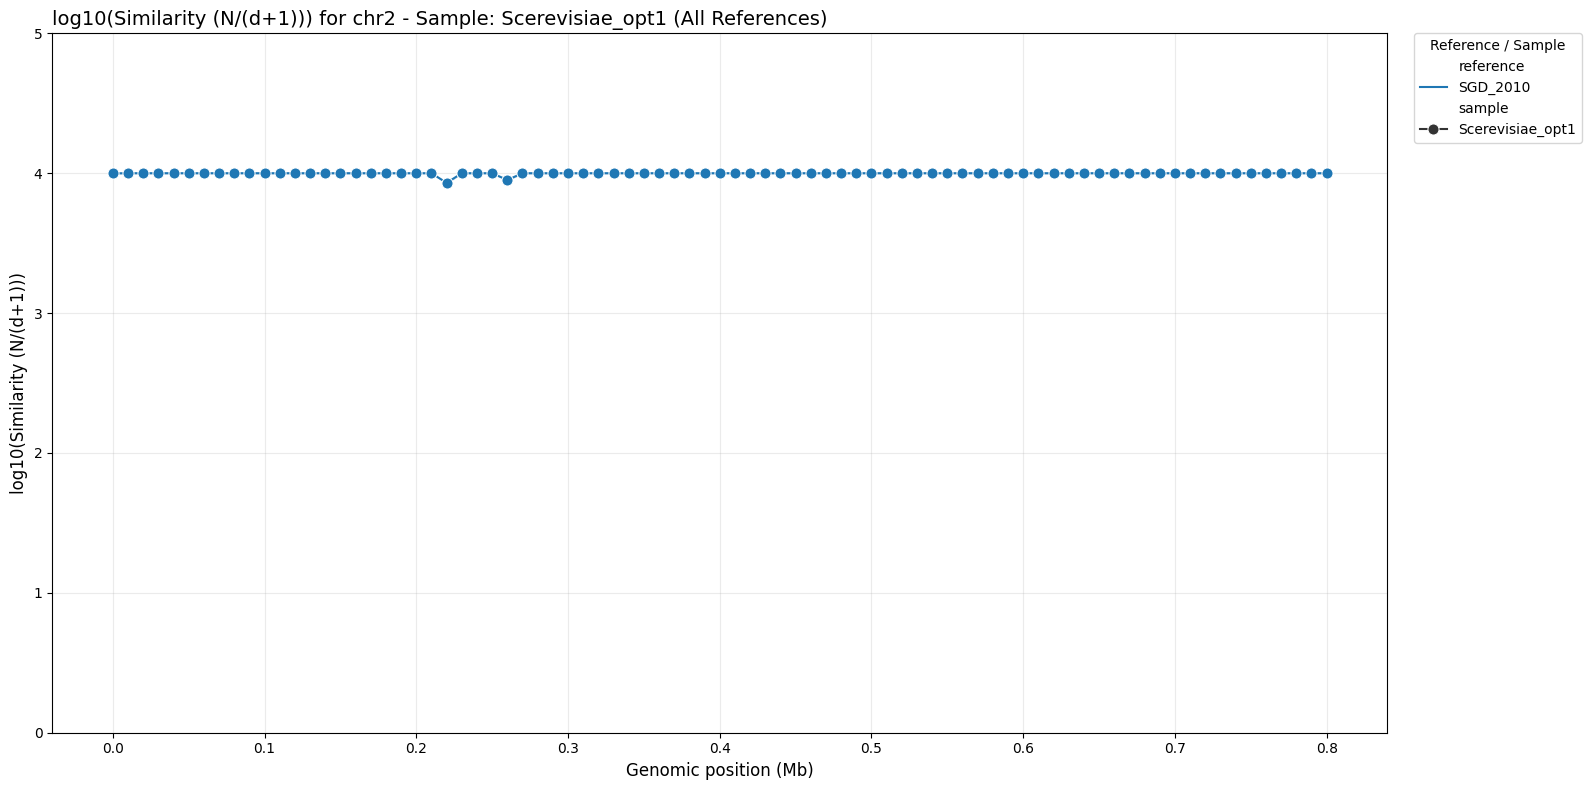

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np # Import numpy for log transformation

# Define SAMPLE_COLORS locally for this example
# Los colores se aplicarán a los nombres de las muestras.
SAMPLE_COLORS = {
    "Scerevisiae_10pct_NO": "#C33B80",
    "Scerevisiae_window_mutated_10pct": "#008F00",
}

# Concatenar *todos* los DataFrames de dfs_chr2_by_reference
df_combined_plot = pd.concat(
    [df for df in dfs_chr2_by_reference.values()],
    ignore_index=True
)

# Variable para seleccionar una sola muestra
SAMPLE_TO_PLOT = 'Scerevisiae_opt1' # Puedes cambiar esta muestra a la que desees

# Filtrar el DataFrame combinado para la muestra seleccionada
df_single_sample_plot = df_combined_plot[df_combined_plot['sample'] == SAMPLE_TO_PLOT].copy()

# Asegurarse de que el DataFrame no esté vacío después de filtrar
if df_single_sample_plot.empty:
    print(f"No se encontraron datos para la muestra '{SAMPLE_TO_PLOT}' en las referencias seleccionadas.")
else:
    # Transform 'similarity_N_over_dplus1' to its log10 value for plotting
    df_single_sample_plot['log10_similarity'] = np.log10(df_single_sample_plot['similarity_N_over_dplus1'])

    # Crear una nueva figura para la gráfica con un tamaño específico
    plt.figure(figsize=(16, 8))

    # Graficar las líneas usando 'reference' para el color y 'sample' para el estilo de línea
    # Esto permite distinguir las muestras por el estilo y las referencias por el color
    sns.lineplot(
        x='start_mb',
        y='log10_similarity', # Plot the log10 transformed values
        data=df_single_sample_plot,
        hue='reference',
        style='sample',
        linewidth=1.5,
        markers=True,
        markersize=8
    )

    plt.title(f'log10(Similarity (N/(d+1))) for chr2 - Sample: {SAMPLE_TO_PLOT} (All References)', loc='left', fontsize=14)
    plt.xlabel('Genomic position (Mb)', fontsize=12)
    plt.ylabel('log10(Similarity (N/(d+1)))', fontsize=12) # Update y-axis label
    plt.ylim(0, 5) # Set y-axis limit from 0 to 4
    # plt.yscale('log') # Remove yscale('log') as data is already log-transformed
    plt.grid(alpha=0.25)
    plt.legend(title='Reference / Sample', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()

In [63]:
print("Valores únicos en la columna 'sample' de df_chr2:")
print(df_combined_plot['sample'].unique())

print("\nValores únicos en la columna 'reference' de df_chr2:")
print(df_combined_plot['reference'].unique())

Valores únicos en la columna 'sample' de df_chr2:
['Scerevisiae_opt1' 'Scerevisiae_opt2' 'Scerevisiae_opt3'
 'Scerevisiae_opt4']

Valores únicos en la columna 'reference' de df_chr2:
['SGD_2010']


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_similarity_for_sample_and_reference(sample_name, references_to_plot, metric='similarity_N_over_dplus1'):
    """
    Genera una gráfica de la métrica de similitud o divergencia para una muestra
    y una o varias referencias específicas en el cromosoma 2.

    Args:
        sample_name (str): El nombre de la muestra a graficar.
        references_to_plot (str or list): El nombre de la referencia o una lista de nombres de referencias a graficar.
        metric (str): La métrica a graficar ('similarity_N_over_dplus1' o 'divergence_d_over_N').
    """

    # Asegurarse de que `references_to_plot` sea una lista para facilitar el filtrado
    if isinstance(references_to_plot, str):
        references_to_plot = [references_to_plot]

    # Check if df_combined_plot exists. If not, inform the user.
    if 'df_combined_plot' not in globals():
        print("Error: `df_combined_plot` no está disponible. Asegúrate de haber ejecutado la celda que lo crea (anterior a la definición de esta función).")
        return

    # Filtrar el DataFrame combinado para la muestra y las referencias seleccionadas
    df_sample_ref_plot = df_combined_plot[
        (df_combined_plot['sample'] == sample_name) &
        (df_combined_plot['reference'].isin(references_to_plot))
    ].copy()

    if df_sample_ref_plot.empty:
        print(f"No se encontraron datos para la muestra '{sample_name}' con las referencias '{', '.join(references_to_plot)}'.")
        return

    plot_metric = metric
    ylabel_text = metric
    apply_ylim_0_5 = False

    if metric == 'similarity_N_over_dplus1':
        df_sample_ref_plot['log10_similarity'] = np.log10(df_sample_ref_plot[metric])
        plot_metric = 'log10_similarity'
        ylabel_text = 'log10(Similarity (N/(d+1)))'
        apply_ylim_0_5 = True

    plt.figure(figsize=(16, 8))
    sns.lineplot(
        x='start_mb',
        y=plot_metric,
        data=df_sample_ref_plot,
        hue='reference',
        linewidth=1.5,
        markers=True,
        markersize=8
    )

    title_metric = 'Similarity' if metric == 'similarity_N_over_dplus1' else 'Divergence'

    if len(references_to_plot) == 1:
        title_refs = f"Reference: {references_to_plot[0]}"
    else:
        title_refs = f"All References"

    plt.title(f'{title_metric} ({metric}) for chr2 - Sample: {sample_name} vs {title_refs}', loc='left', fontsize=14)
    plt.xlabel('Genomic position (Mb)', fontsize=12)
    plt.ylabel(ylabel_text, fontsize=12)

    if apply_ylim_0_5:
        plt.ylim(0, 5)

    plt.grid(alpha=0.25)
    plt.legend(title='Reference', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()

### Ejemplo de uso de la función `plot_similarity_for_sample_and_reference`

Ahora puedes usar la función para graficar cualquier combinación de muestra y referencia. Simplemente cambia los valores de `chosen_sample` y `chosen_reference`.

In [66]:
unique_refer_in_combined_plot = df_combined_plot['reference'].unique().tolist()
print("Lista de referencias únicas en df_combined_plot:")
for refer in unique_refer_in_combined_plot:
    print(f"- {refer}")

Lista de referencias únicas en df_combined_plot:
- SGD_2010


In [67]:
unique_samp_in_combined_plot = df_combined_plot['sample'].unique().tolist()
print("Lista de samples únicas en df_combined_plot:")
for samp in unique_samp_in_combined_plot:
    print(f"- {samp}")

Lista de samples únicas en df_combined_plot:
- Scerevisiae_opt1
- Scerevisiae_opt2
- Scerevisiae_opt3
- Scerevisiae_opt4


Generando gráfica para la referencia: Scerevisiae_opt1


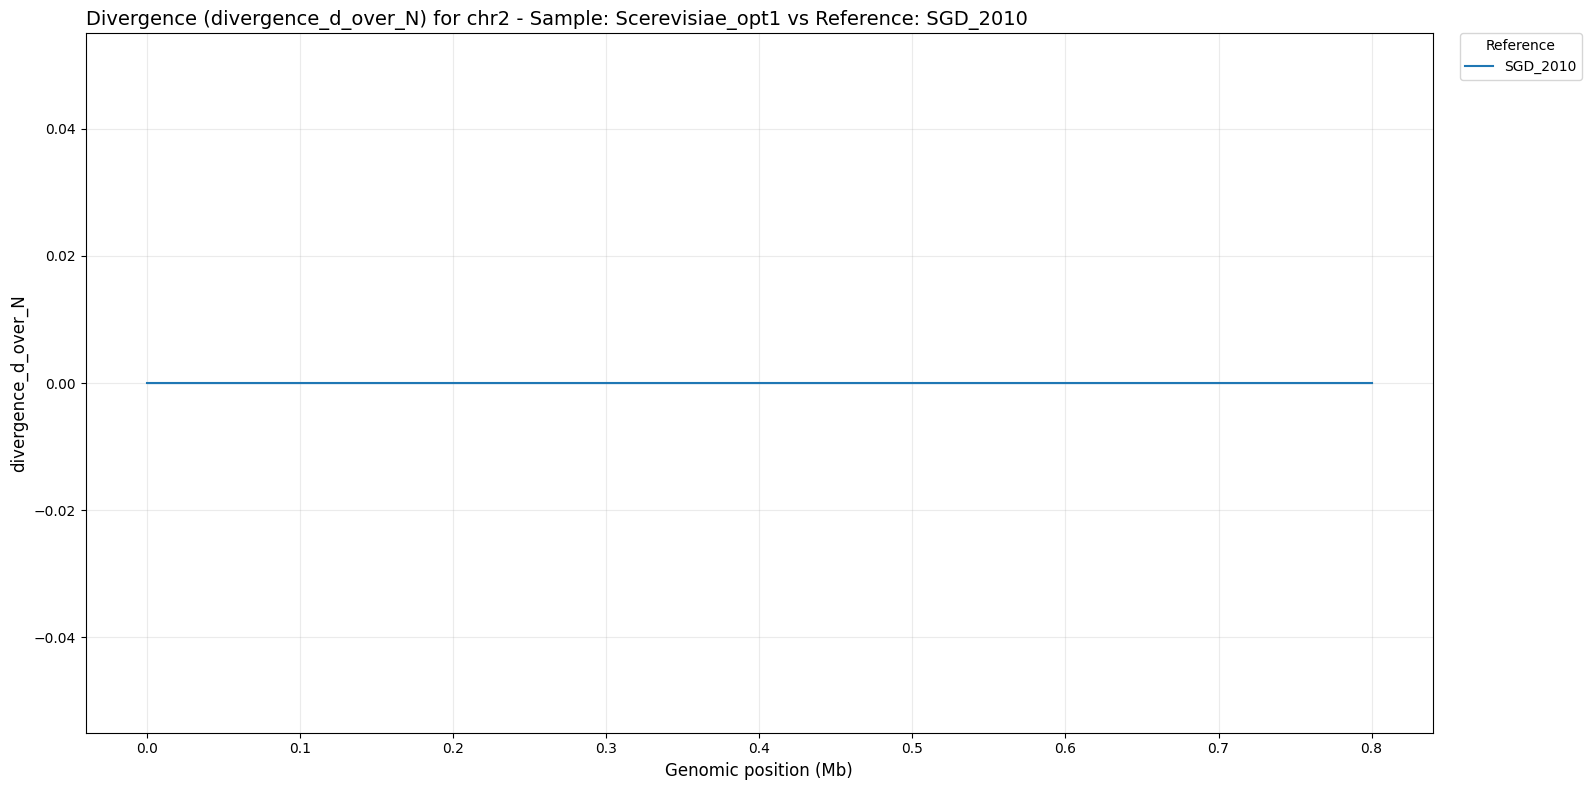

Generando gráfica para la referencia: Scerevisiae_opt2


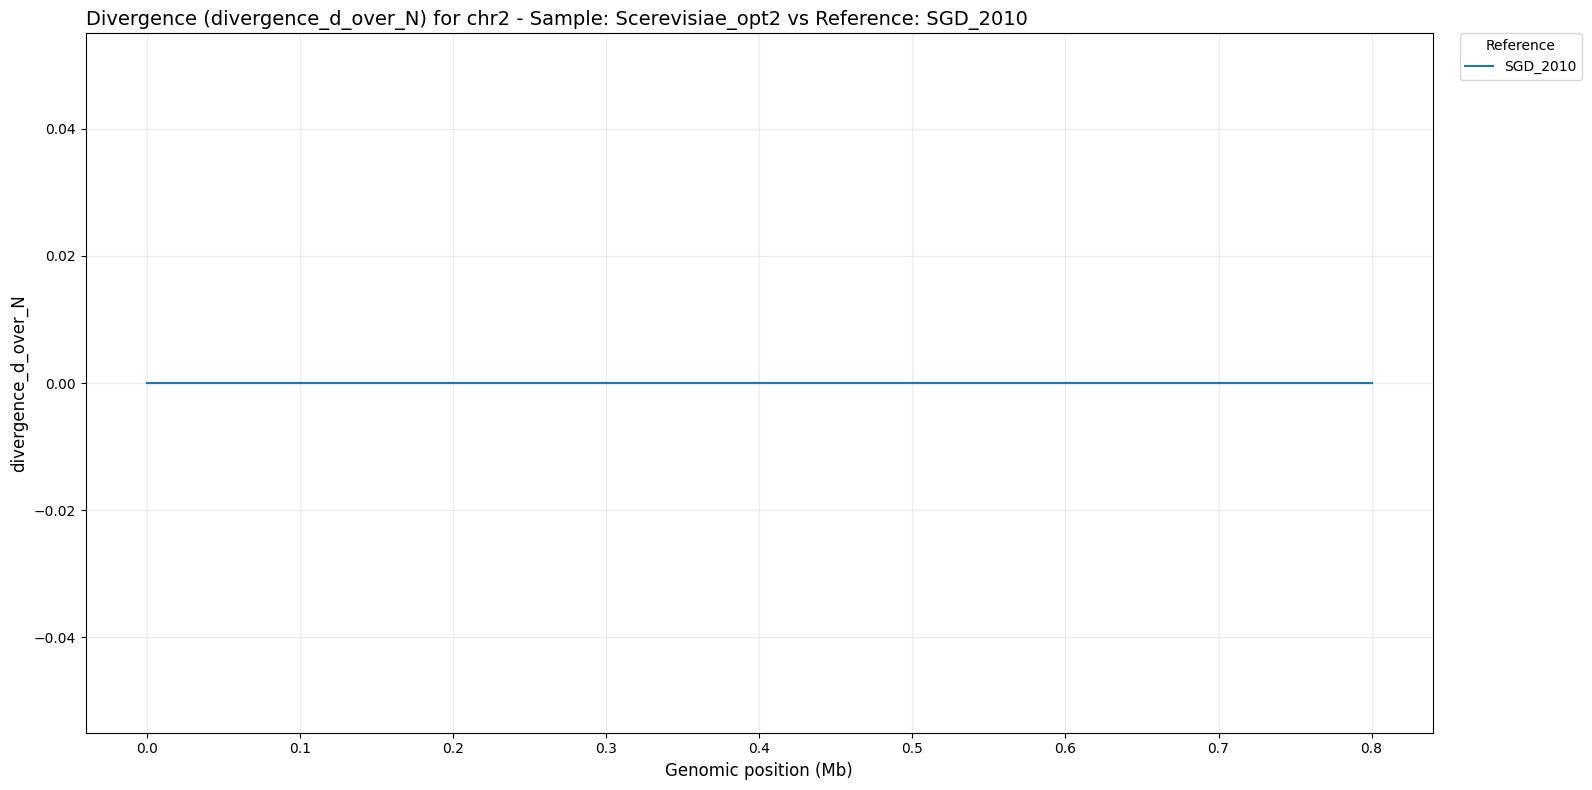

Generando gráfica para la referencia: Scerevisiae_opt3


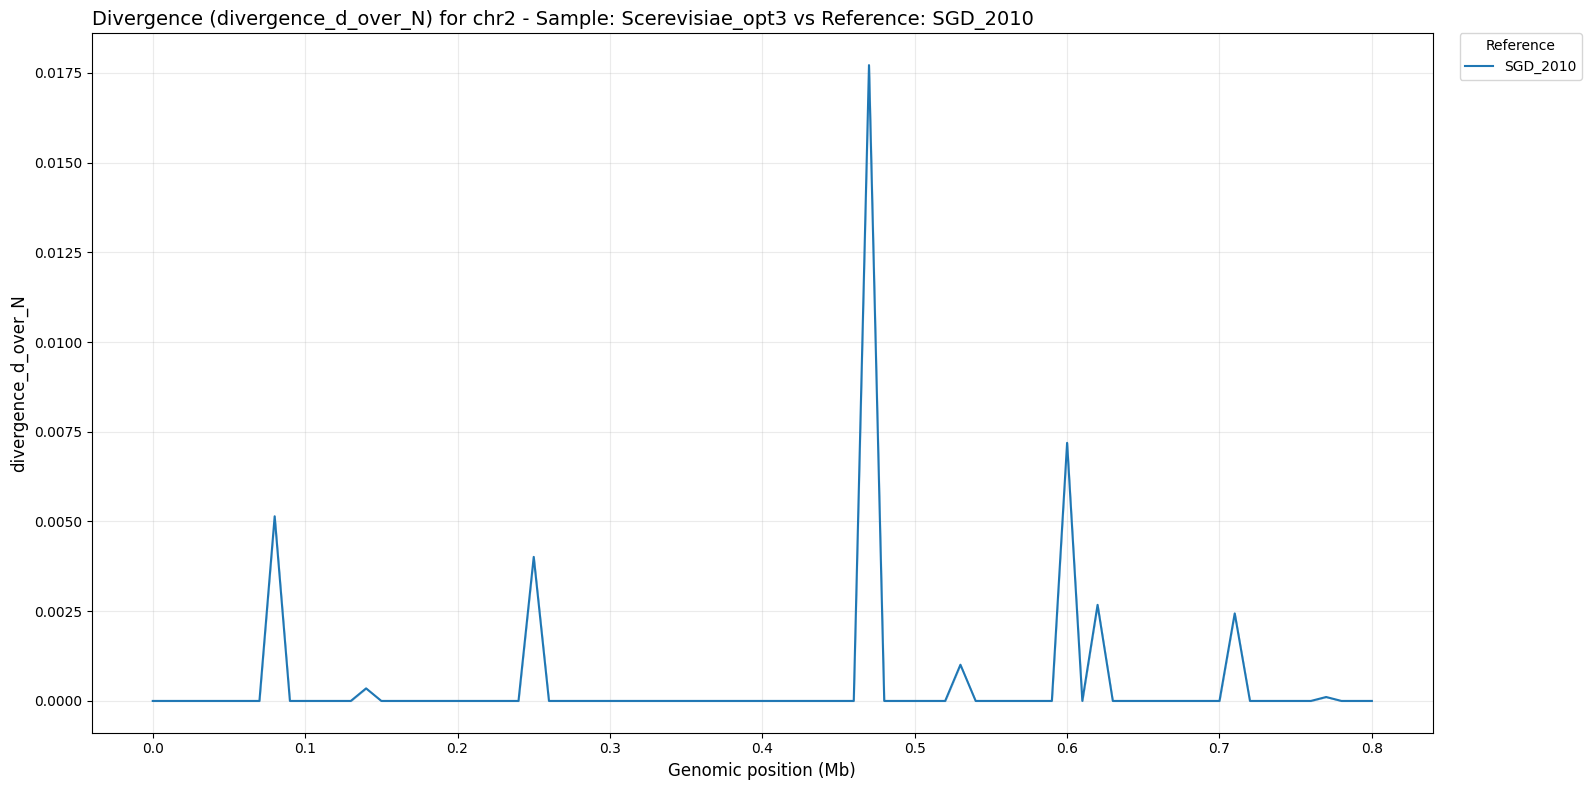

Generando gráfica para la referencia: Scerevisiae_opt4


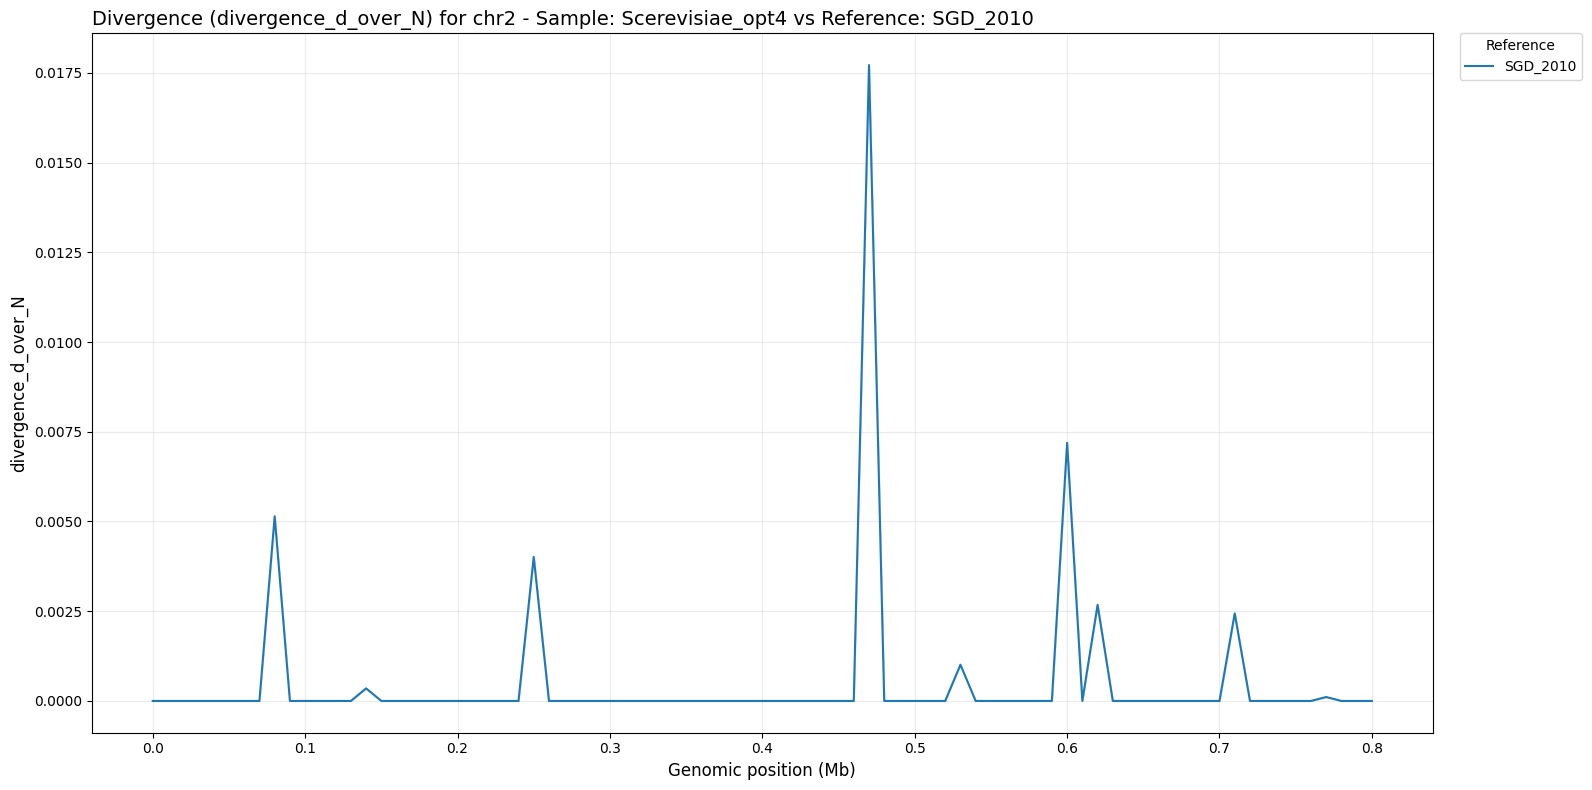

In [68]:
# Ensure df_combined_plot is available from a previous cell like c4M6MEqlqyK7
# If this cell is run independently, df_combined_plot might not be defined.
if 'df_combined_plot' not in globals():
    print("Error: `df_combined_plot` no está disponible. Asegúrate de haber ejecutado la celda que lo crea (anterior a la definición de esta función).")
else:
    unique_refer_in_combined_plot = df_combined_plot['reference'].unique().tolist()
    unique_samp_in_combined_plot = df_combined_plot['sample'].unique().tolist()

    chosen_sample = unique_samp_in_combined_plot
    chosen_references_list = unique_refer_in_combined_plot # Esto ya contiene todas tus referencias

    for samp in chosen_sample:
        print(f"Generando gráfica para la referencia: {samp}")
        plot_similarity_for_sample_and_reference(samp, chosen_references_list, metric='divergence_d_over_N')
    # Removed: plt.ylim(0, 4) as ylim is now handled conditionally inside the plotting function.

Generando gráfica para la referencia: Scerevisiae_opt1


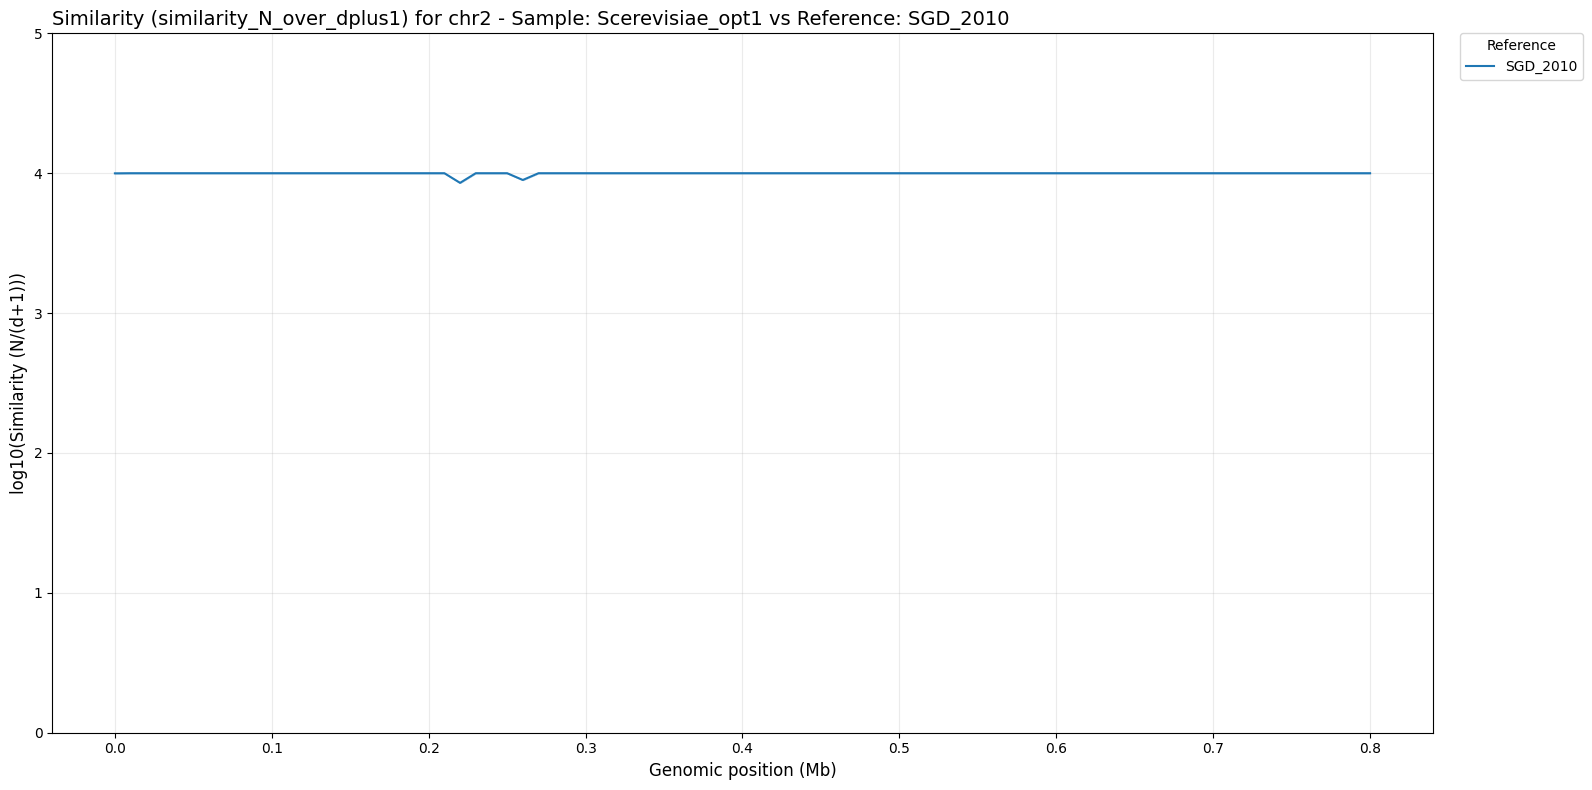

Generando gráfica para la referencia: Scerevisiae_opt2


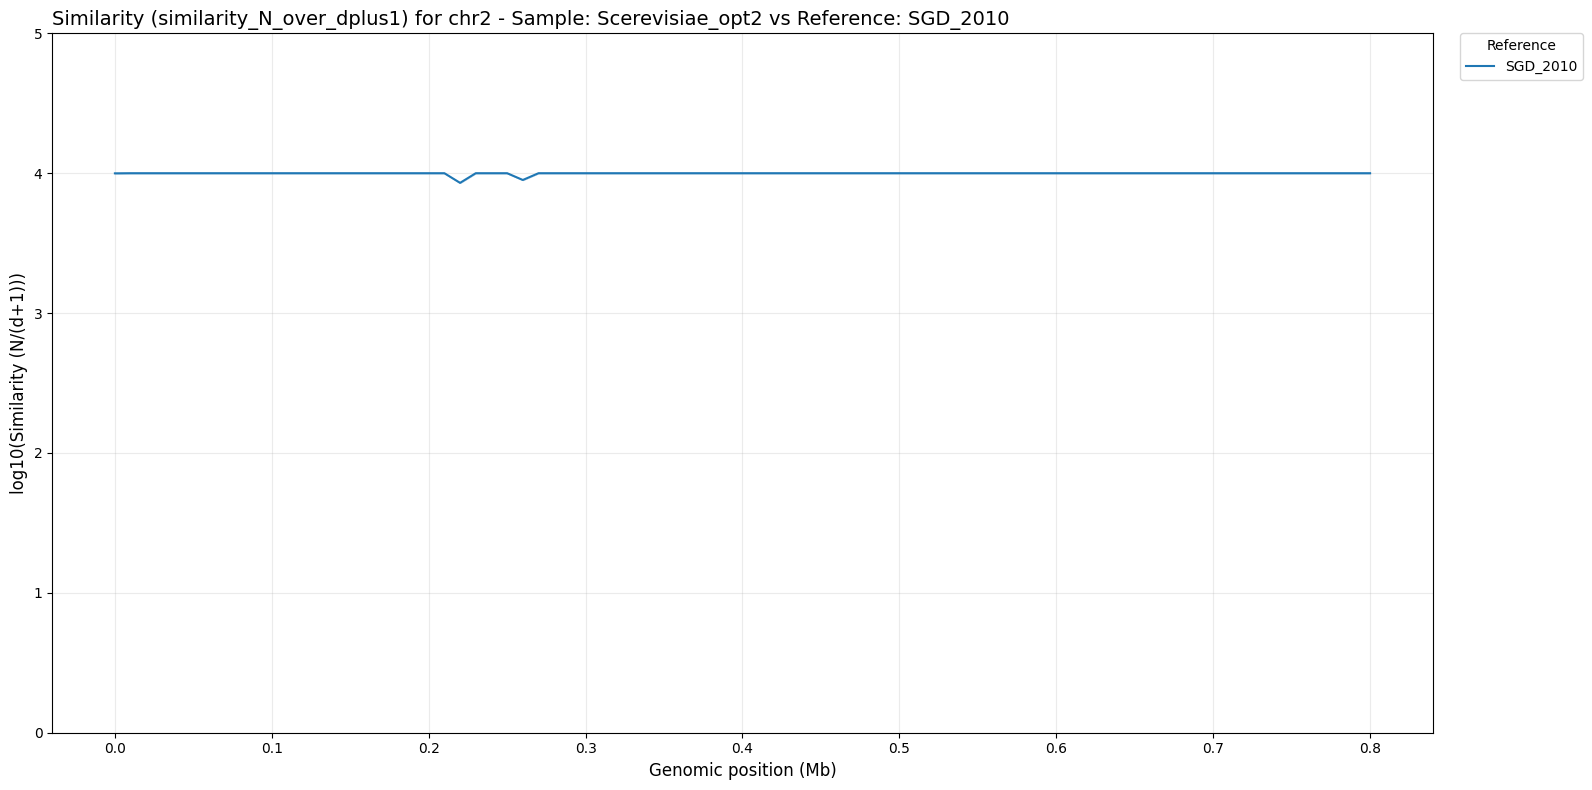

Generando gráfica para la referencia: Scerevisiae_opt3


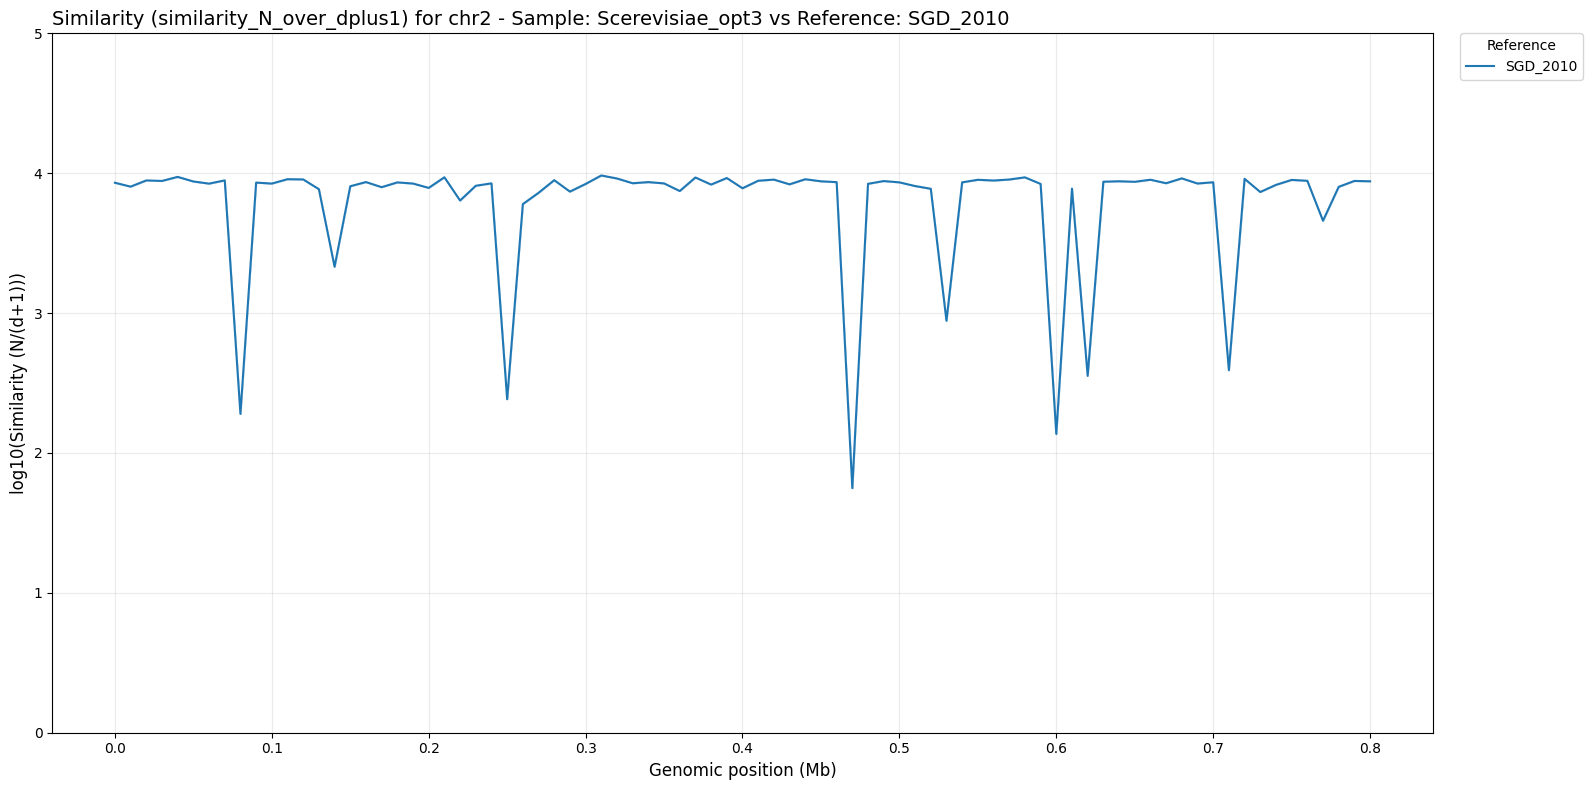

Generando gráfica para la referencia: Scerevisiae_opt4


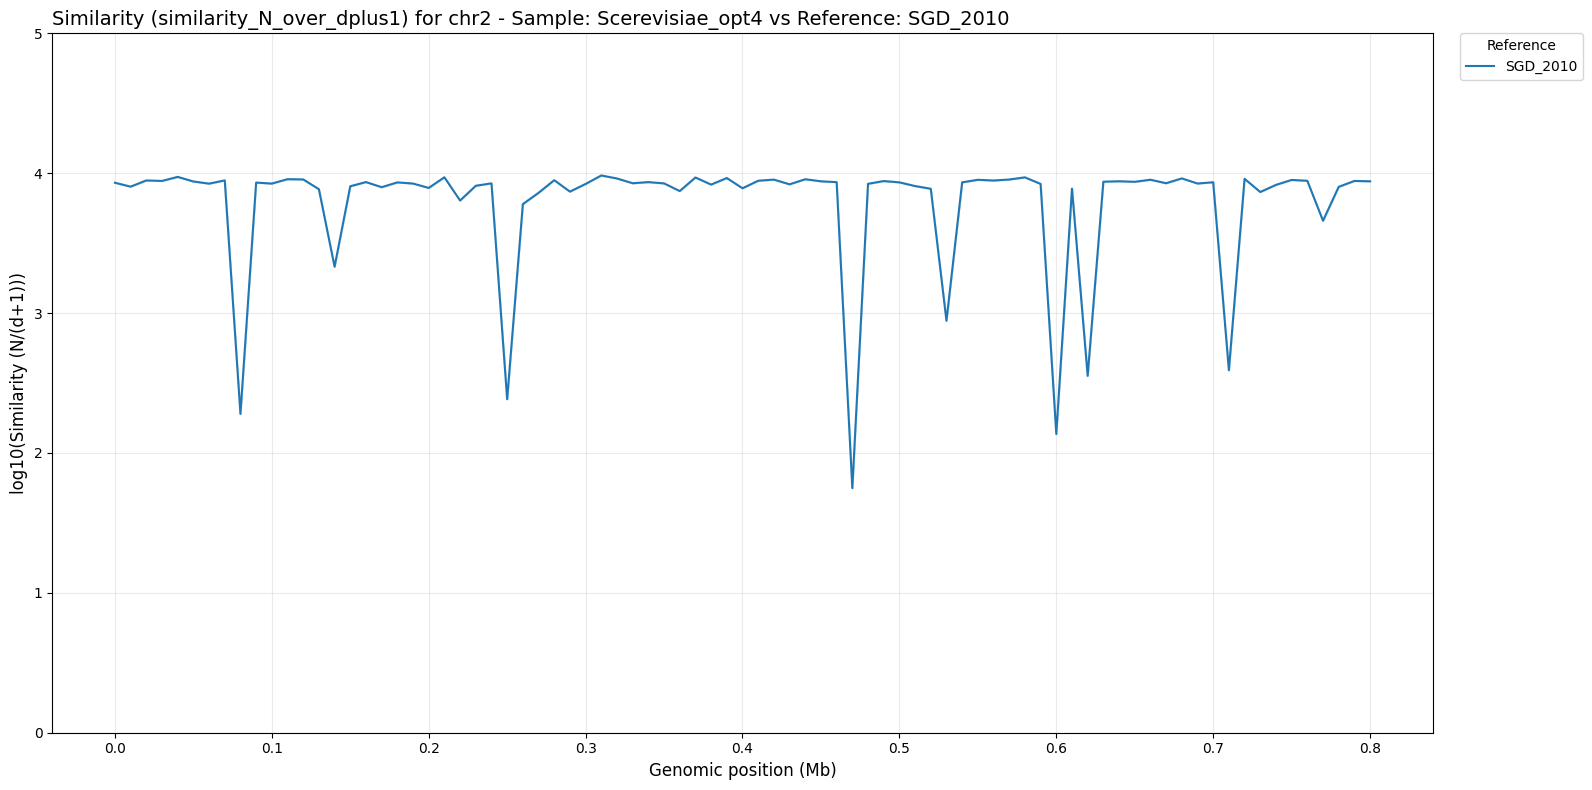

In [69]:
# Ensure df_combined_plot is available from a previous cell like c4M6MEqlqyK7
# If this cell is run independently, df_combined_plot might not be defined.
if 'df_combined_plot' not in globals():
    print("Error: `df_combined_plot` no está disponible. Asegúrate de haber ejecutado la celda que lo crea (anterior a la definición de esta función).")
else:
    unique_refer_in_combined_plot = df_combined_plot['reference'].unique().tolist()
    unique_samp_in_combined_plot = df_combined_plot['sample'].unique().tolist()

    chosen_sample = unique_samp_in_combined_plot
    chosen_references_list = unique_refer_in_combined_plot # Esto ya contiene todas tus referencias

    for samp in chosen_sample:
        print(f"Generando gráfica para la referencia: {samp}")
        plot_similarity_for_sample_and_reference(samp, chosen_references_list, metric='similarity_N_over_dplus1')
    # Removed: plt.ylim(0, 4) as ylim is now handled conditionally inside the plotting function.

### Graficar una muestra específica contra todas las referencias

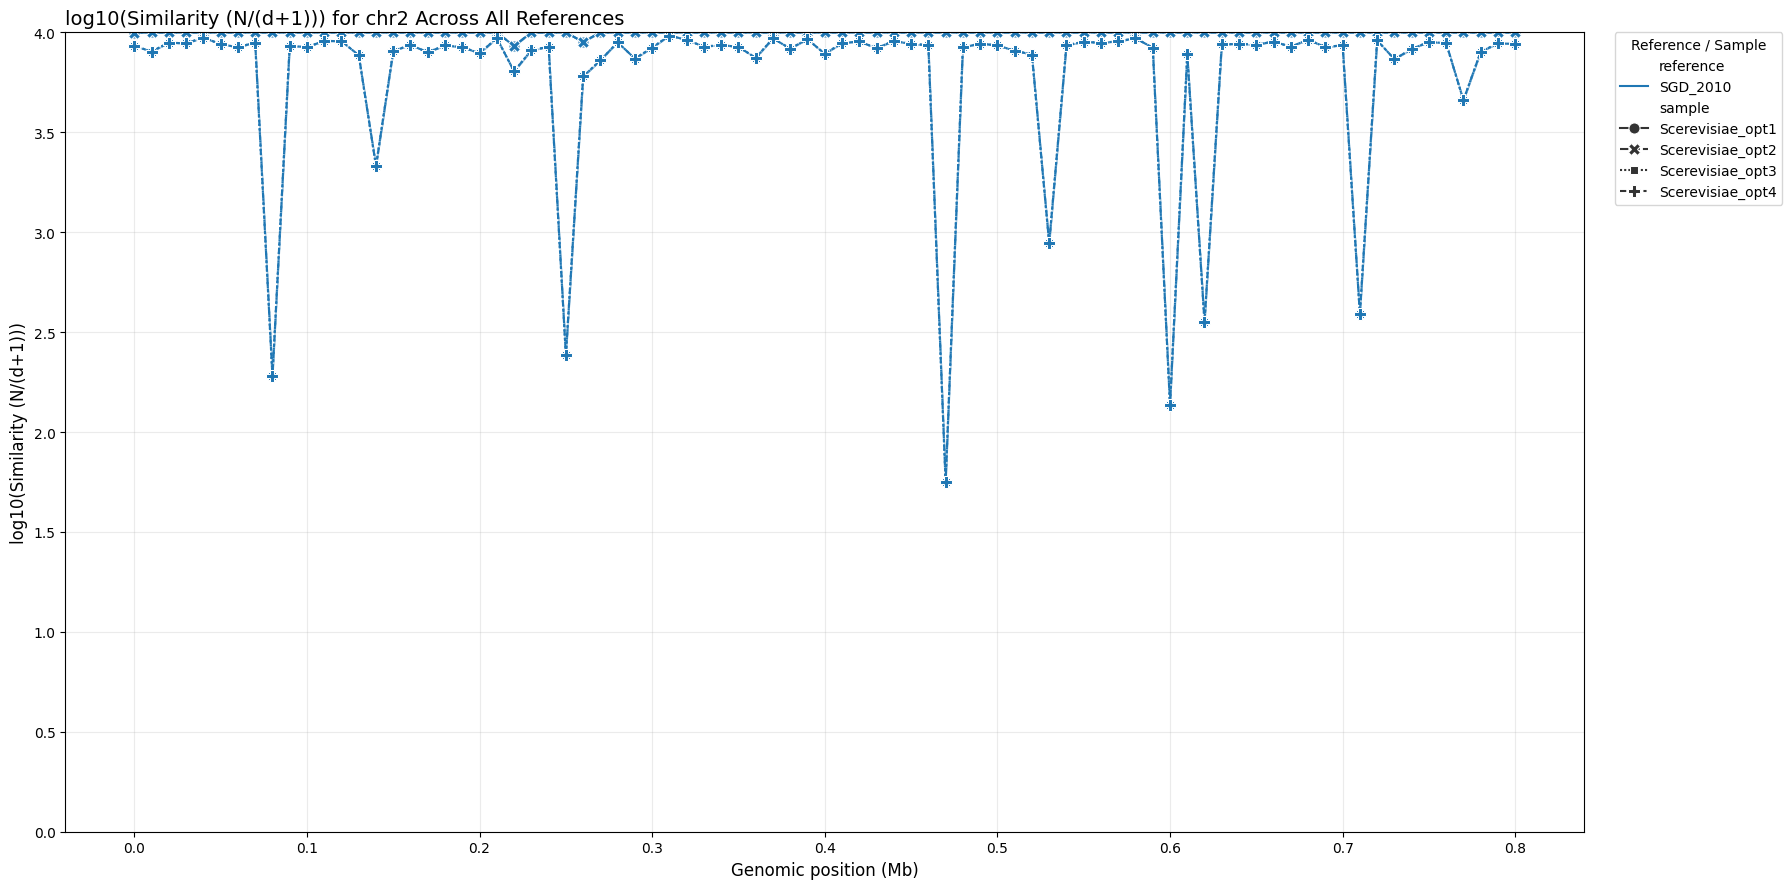

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np # Import numpy for log transformation

# Combine all DataFrames from dfs_chr2_by_reference
# into a single DataFrame for plotting all references together.
df_combined_plot_all_refs = pd.concat(
    [df for df in dfs_chr2_by_reference.values()],
    ignore_index=True
)

# Transform 'similarity_N_over_dplus1' to its log10 value for plotting
df_combined_plot_all_refs['log10_similarity'] = np.log10(df_combined_plot_all_refs['similarity_N_over_dplus1'])

# Create a new figure for the plot with a specific size
plt.figure(figsize=(18, 9)) # Slightly larger figure for more data

# Plot the lines using 'reference' for color and 'sample' for line style.
# This allows distinguishing samples by line style and references by color.
sns.lineplot(
    x='start_mb',
    y='log10_similarity', # Plot the log10 transformed values
    data=df_combined_plot_all_refs,
    hue='reference', # Color distinguishes references
    style='sample',  # Line style distinguishes samples
    linewidth=1.5,
    markers=True, # Add markers to data points
    markersize=8 # Adjust marker size
)

plt.title('log10(Similarity (N/(d+1))) for chr2 Across All References', loc='left', fontsize=14)
plt.xlabel('Genomic position (Mb)', fontsize=12)
plt.ylabel('log10(Similarity (N/(d+1)))', fontsize=12) # Update y-axis label
plt.ylim(0, 4) # Set y-axis limit from 0 to 4
# plt.yscale('log') # Remove yscale('log') as data is already log-transformed
plt.grid(alpha=0.25)
plt.legend(title='Reference / Sample', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

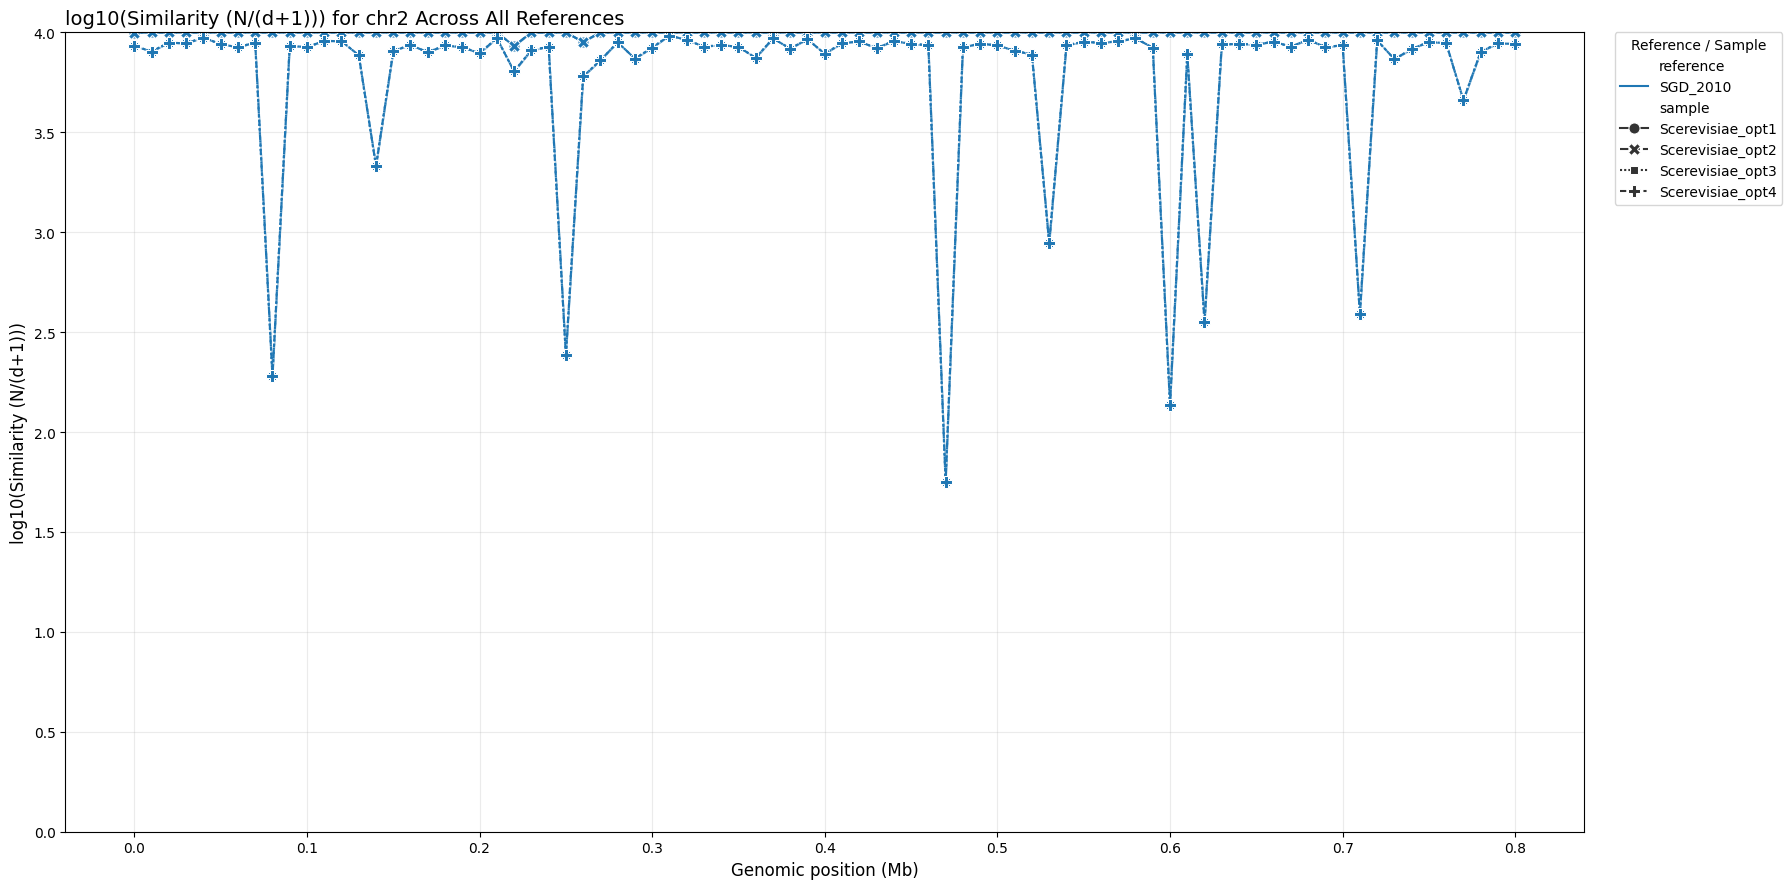

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np # Import numpy for log transformation

# Combine all DataFrames from dfs_chr2_by_reference
# into a single DataFrame for plotting all references together.
df_combined_plot_all_refs = pd.concat(
    [df for df in dfs_chr2_by_reference.values()],
    ignore_index=True
)

# Transform 'similarity_N_over_dplus1' to its log10 value for plotting
df_combined_plot_all_refs['log10_similarity'] = np.log10(df_combined_plot_all_refs['similarity_N_over_dplus1'])

# Create a new figure for the plot with a specific size
plt.figure(figsize=(18, 9)) # Slightly larger figure for more data

# Plot the lines using 'reference' for color and 'sample' for line style.
# This allows distinguishing samples by line style and references by color.
sns.lineplot(
    x='start_mb',
    y='log10_similarity', # Plot the log10 transformed values
    data=df_combined_plot_all_refs,
    hue='reference', # Color distinguishes references
    style='sample',  # Line style distinguishes samples
    linewidth=1.5,
    markers=True, # Add markers to data points
    markersize=8 # Adjust marker size
)

plt.title('log10(Similarity (N/(d+1))) for chr2 Across All References', loc='left', fontsize=14)
plt.xlabel('Genomic position (Mb)', fontsize=12)
plt.ylabel('log10(Similarity (N/(d+1)))', fontsize=12) # Update y-axis label
plt.ylim(0, 4) # Set y-axis limit from 0 to 4
# plt.yscale('log') # Remove yscale('log') as data is already log-transformed
plt.grid(alpha=0.25)
plt.legend(title='Reference / Sample', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter out the 'scer' reference from the dictionary
dfs_chr2_by_reference_filtered = {k: v for k, v in dfs_chr2_by_reference.items() if k != 'scer'}


# Combine all DataFrames from dfs_chr2_by_reference
# into a single DataFrame for plotting all references together.
df_combined_plot_filtered_divergence = pd.concat(

#df_combined_plot_all_refs_divergence = pd.concat(
    [df for df in dfs_chr2_by_reference_filtered.values()],
    ignore_index=True
)

# Create a new figure for the plot with a specific size
plt.figure(figsize=(18, 9)) # Slightly larger figure for more data

# Plot the lines using 'reference' for color and 'sample' for line style.
# This allows distinguishing samples by line style and references by color.
sns.lineplot(
    x='start_mb',
    y='divergence_d_over_N', # Change to the new metric
    data=df_combined_plot_filtered_divergence ,
    hue='reference', # Color distinguishes references
    style='sample',  # Line style distinguishes samples
    linewidth=1.5,
    markers=True, # Add markers to data points
    markersize=8 # Adjust marker size
)

plt.title('Divergence (d/N) for chr2 Across All References', loc='left', fontsize=14) # Update title
plt.xlabel('Genomic position (Mb)', fontsize=12)
plt.ylabel('Divergence (d/N)', fontsize=12) # Update y-axis label
# plt.yscale('log') # Log scale might not be appropriate for divergence, remove or adjust if needed
plt.grid(alpha=0.25)
plt.legend(title='Reference / Sample', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter out the 'scer' reference from the dictionary
dfs_chr2_by_reference_filtered = {k: v for k, v in dfs_chr2_by_reference.items() if k != 'scer'}

# Combine the filtered DataFrames into a single DataFrame
df_combined_plot_filtered_divergence = pd.concat(
    [df for df in dfs_chr2_by_reference_filtered.values()],
    ignore_index=True
)

# Create a new figure for the plot with a specific size
plt.figure(figsize=(18, 9)) # Slightly larger figure for more data

# Plot the lines using 'reference' for color and 'sample' for line style.
sns.lineplot(
    x='start_mb',
    y='divergence_d_over_N', # Use the divergence metric
    data=df_combined_plot_filtered_divergence,
    hue='reference', # Color distinguishes references
    style='sample',  # Line style distinguishes samples
    linewidth=1.5,
    markers=True, # Add markers to data points
    markersize=8 # Adjust marker size
)

plt.title('Divergence (d/N) for chr2 Across References (excluding scer)', loc='left', fontsize=14) # Update title
plt.xlabel('Genomic position (Mb)', fontsize=12)
plt.ylabel('Divergence (d/N)', fontsize=12) # Update y-axis label
plt.grid(alpha=0.25)
plt.legend(title='Reference / Sample', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Identificar la mejor referencia por muestra

In [ ]:
# Cargar y agregar las métricas de todas las referencias
aggregated_results = aggregate_metrics_across_all_chromosomes(references)

if not aggregated_results.empty:
    # Para cada muestra, encontrar la referencia con la menor divergencia (o mayor similitud)
    # Usaremos la divergencia para encontrar el 'mejor' match (el valor más bajo)
    best_matches_divergence = aggregated_results.loc[aggregated_results.groupby('sample')['overall_divergence_d_over_N'].idxmin()]

    print("\n--- Mejor referencia por muestra (menor divergencia) ---")
    display(best_matches_divergence.sort_values(by='sample'))

    # También podemos encontrar la referencia con la mayor similitud
    best_matches_similarity = aggregated_results.loc[aggregated_results.groupby('sample')['overall_similarity_N_over_dplus1'].idxmax()]

    print("\n--- Mejor referencia por muestra (mayor similitud) ---")
    display(best_matches_similarity.sort_values(by='sample'))
else:
    print("No se encontraron resultados agregados para analizar.")


## 8. Agregación de métricas por cromosoma

In [ ]:
def aggregate_metrics_by_chromosome(references):
    all_chrom_aggregated_data = []

    print("Agregando métricas por cromosoma para todas las referencias...")
    for ref_name in references:
        try:
            df_ref = load_reference_tables(ref_name)
            # Agrupar por muestra, referencia y cromosoma, y sumar N_sites y SNPs_d
            aggregated_df = df_ref.groupby(['sample', 'reference', 'chrom']).agg(
                total_N_sites=('N_sites', 'sum'),
                total_SNPs_d=('SNPs_d', 'sum')
            ).reset_index()

            # Recalcular las métricas a nivel de cromosoma
            aggregated_df['chrom_divergence_d_over_N'] = aggregated_df['total_SNPs_d'] / aggregated_df['total_N_sites']
            aggregated_df['chrom_similarity_N_over_dplus1'] = aggregated_df['total_N_sites'] / (aggregated_df['total_SNPs_d'] + 1)

            all_chrom_aggregated_data.append(aggregated_df)
            print(f"  - Datos agregados por cromosoma para la referencia: {ref_name}")

        except FileNotFoundError:
            print(f"  - Advertencia: No se encontraron archivos para la referencia {ref_name}. Saltando...")
        except Exception as e:
            print(f"  - Error al procesar la referencia {ref_name}: {e}")

    if not all_chrom_aggregated_data:
        print("No se pudieron agregar datos por cromosoma para ninguna referencia.")
        return pd.DataFrame()

    final_df = pd.concat(all_chrom_aggregated_data, ignore_index=True)

    # Convertir 'chrom' a tipo categórico para ordenar correctamente en el plot
    all_chroms = sorted(final_df['chrom'].unique(), key=natural_chr_key)
    final_df['chrom'] = pd.Categorical(final_df['chrom'], categories=all_chroms, ordered=True)

    return final_df

In [ ]:
# Agregamos las métricas por cromosoma para todas las referencias
chrom_aggregated_results = aggregate_metrics_by_chromosome(references)

print("Primeras filas de los resultados agregados por cromosoma:")
display(chrom_aggregated_results.head())
